# 07 — Bersihkan `easy_clean.jsonl`

Buang/perbaiki baris rusak yang ketemu pas sampling manual: jawaban cuma huruf pilgan (A-E), soal masih ada blok opsi A-E utuh, `cara` model ngaku bingung/karang soal sendiri, dan soal berbahasa Inggris nyelip.

Alur: load -> klasifikasi tiap baris (KEEP / REPAIR / drop-reason) -> simpan hasil bersih + baris dibuang + laporan -> visualisasi before/after buat verifikasi manual.

In [1]:
import json, re, random
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# cari root repo (folder yang punya src/), biar notebook jalan dari mana aja
_p = Path.cwd()
while not (_p / "src").exists() and _p != _p.parent:
    _p = _p.parent
import sys
sys.path.insert(0, str(_p))
REPO_ROOT = _p

from src.preprop.filter_rules import is_multiple_choice
from src.cot_synthesis.to_chatml import is_indonesian

INPUT = REPO_ROOT / "data/Final/easy_clean.jsonl"
OUT_CLEAN = REPO_ROOT / "data/Final/easy_clean_v2.jsonl"
OUT_DROPPED = REPO_ROOT / "data/Final/easy_clean_v2_dropped.jsonl"
OUT_REPORT = REPO_ROOT / "data/Final/easy_clean_v2_report.txt"

rows = [json.loads(l) for l in open(INPUT, encoding="utf-8") if l.strip()]
print(f"loaded {len(rows)} rows from {INPUT}")

loaded 2686 rows from C:\Users\Henry\Documents\KULIAH\sem_4\NLP\FP\data\Final\easy_clean.jsonl


In [2]:
BARE_LETTER = re.compile(r"^[A-E]$")
LETTER_VALUE = re.compile(r"^([A-E])\.\s*(.+)$", re.S)

# frasa yang muncul kalau LLM ngaku soal aslinya kepotong/nggak lengkap terus ngarang sendiri
CONFUSION_PHRASES = [
    "kita perlu lebih banyak informasi",
    "saya perlu melihat soal aslinya",
    "berdasarkan informasi yang diberikan, saya akan membuat",
    "namun, tanpa informasi lebih lanjut",
    "tanpa informasi tambahan yang lengkap",
    "kita tidak memiliki informasi",
    "namun, kita perlu lebih jelas",
]

def cara_fabricated(cara: str) -> bool:
    c = (cara or "").lower()
    return any(p in c for p in CONFUSION_PHRASES)

def classify(row: dict) -> str:
    """'KEEP' | 'REPAIR' | drop-reason string. Urutan cek = prioritas (biar nggak dobel-hitung)."""
    jawaban = (row.get("jawaban") or "").strip()
    soal = row.get("soal") or ""
    cara = row.get("cara") or ""

    if BARE_LETTER.match(jawaban):
        return "jawaban_bare_letter"
    if is_multiple_choice(soal):
        return "mc_block_in_soal"
    if cara_fabricated(cara):
        return "cara_fabricated"
    if soal.strip() and not is_indonesian(soal):
        return "english_leak"
    if LETTER_VALUE.match(jawaban):
        return "REPAIR"
    return "KEEP"

In [3]:
reasons = Counter()
cleaned, dropped = [], []

for r in rows:
    verdict = classify(r)
    reasons[verdict] += 1
    if verdict == "KEEP":
        cleaned.append(r)
    elif verdict == "REPAIR":
        m = LETTER_VALUE.match(r["jawaban"].strip())
        r2 = dict(r)
        r2["jawaban"] = m.group(2).strip()
        r2["_repair"] = "stripped_letter_prefix"
        cleaned.append(r2)
    else:
        r2 = dict(r)
        r2["_dropped_reason"] = verdict
        dropped.append(r2)

assert len(cleaned) + len(dropped) == len(rows)

OUT_CLEAN.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_CLEAN, "w", encoding="utf-8") as f:
    for r in cleaned:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
with open(OUT_DROPPED, "w", encoding="utf-8") as f:
    for r in dropped:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

report = [
    "EASY_CLEAN v2 -- LAPORAN PEMBERSIHAN", "=" * 40, "",
    f"Input: {INPUT}", f"Total baris: {len(rows)}", "",
    f"Dipertahankan (kept + repaired): {len(cleaned)} ({100*len(cleaned)/len(rows):.1f}%)",
    f"Dibuang: {len(dropped)} ({100*len(dropped)/len(rows):.1f}%)", "",
    "RINCIAN PER ALASAN", "-" * 40,
]
for reason, n in reasons.most_common():
    report.append(f"{reason:24s} {n:5d}  ({100*n/len(rows):.1f}%)")
report += ["", f"Output bersih   -> {OUT_CLEAN}", f"Baris dibuang   -> {OUT_DROPPED}"]
OUT_REPORT.write_text("\n".join(report), encoding="utf-8")
print("\n".join(report))

EASY_CLEAN v2 -- LAPORAN PEMBERSIHAN

Input: C:\Users\Henry\Documents\KULIAH\sem_4\NLP\FP\data\Final\easy_clean.jsonl
Total baris: 2686

Dipertahankan (kept + repaired): 2336 (87.0%)
Dibuang: 350 (13.0%)

RINCIAN PER ALASAN
----------------------------------------
KEEP                      2229  (83.0%)
jawaban_bare_letter        278  (10.3%)
REPAIR                     107  (4.0%)
english_leak                50  (1.9%)
cara_fabricated             22  (0.8%)

Output bersih   -> C:\Users\Henry\Documents\KULIAH\sem_4\NLP\FP\data\Final\easy_clean_v2.jsonl
Baris dibuang   -> C:\Users\Henry\Documents\KULIAH\sem_4\NLP\FP\data\Final\easy_clean_v2_dropped.jsonl


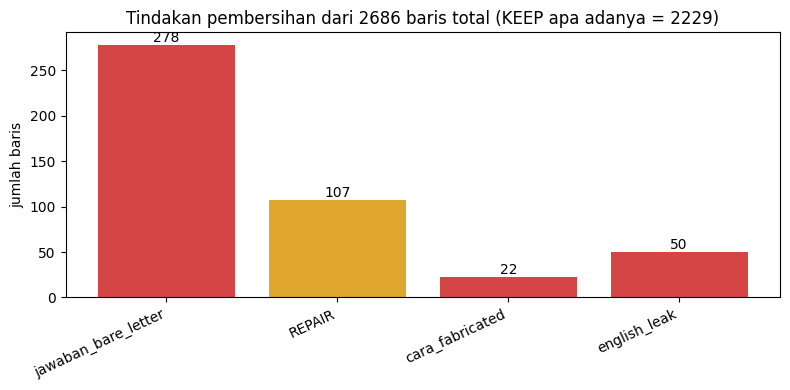

In [4]:
# Visualisasi 1: berapa baris kena tindakan apa (dari total, KEEP tidak diplot)
labels = [r for r in reasons if r != "KEEP"]
counts = [reasons[r] for r in labels]
colors = ["#e0a72e" if l == "REPAIR" else "#d64545" for l in labels]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, counts, color=colors)
plt.ylabel("jumlah baris")
plt.title(f"Tindakan pembersihan dari {len(rows)} baris total (KEEP apa adanya = {reasons['KEEP']})")
plt.xticks(rotation=25, ha="right")
for b, c in zip(bars, counts):
    plt.text(b.get_x() + b.get_width() / 2, c, str(c), ha="center", va="bottom")
plt.tight_layout()
plt.show()

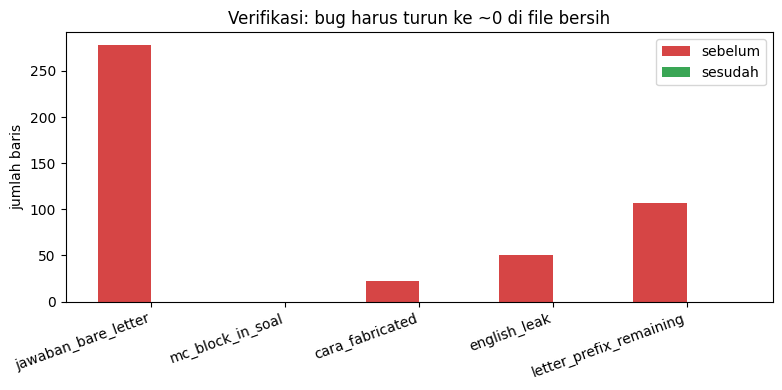


OK -- semua deteksi kritis (bare letter, letter-prefix) = 0 di output bersih.


In [5]:
# Visualisasi 2: jalankan ulang detektor yang sama di file OUTPUT -- harus turun ke ~0
recheck = Counter()
for r in cleaned:
    jawaban = (r.get("jawaban") or "").strip()
    soal = r.get("soal") or ""
    cara = r.get("cara") or ""
    if BARE_LETTER.match(jawaban):
        recheck["jawaban_bare_letter"] += 1
    if is_multiple_choice(soal):
        recheck["mc_block_in_soal"] += 1
    if cara_fabricated(cara):
        recheck["cara_fabricated"] += 1
    if soal.strip() and not is_indonesian(soal):
        recheck["english_leak"] += 1
    if LETTER_VALUE.match(jawaban):
        recheck["letter_prefix_remaining"] += 1

check_labels = ["jawaban_bare_letter", "mc_block_in_soal", "cara_fabricated", "english_leak", "letter_prefix_remaining"]
before_vals = [reasons.get(l, 0) if l != "letter_prefix_remaining" else reasons.get("REPAIR", 0) for l in check_labels]
after_vals = [recheck.get(l, 0) for l in check_labels]

x = range(len(check_labels))
plt.figure(figsize=(8, 4))
plt.bar([i - 0.2 for i in x], before_vals, width=0.4, label="sebelum", color="#d64545")
plt.bar([i + 0.2 for i in x], after_vals, width=0.4, label="sesudah", color="#3aa655")
plt.xticks(list(x), check_labels, rotation=20, ha="right")
plt.ylabel("jumlah baris")
plt.title("Verifikasi: bug harus turun ke ~0 di file bersih")
plt.legend()
plt.tight_layout()
plt.show()

for reason, n in recheck.items():
    if n:
        print(f"WARNING: masih ada {n} baris kena '{reason}' di output bersih")

assert recheck.get("jawaban_bare_letter", 0) == 0, "masih ada bare-letter jawaban lolos"
assert recheck.get("letter_prefix_remaining", 0) == 0, "masih ada letter-prefix belum ke-strip"
print("\nOK -- semua deteksi kritis (bare letter, letter-prefix) = 0 di output bersih.")

=== CONTOH BARIS DIBUANG ===
[english_leak] soal: 'Let $CH$ be an altitude of $\triangle ABC$. Let $R$ and $S$ be, respectively, points at which the cir'
    jawaban: '$RS = \\frac{332}{665}$'

[jawaban_bare_letter] soal: 'Jumlah 20 suku pertama deret tersebut adalah ...\\nA. -580\\nB. -490\\nC. -440\\nD. -410\\nE. -380'
    jawaban: 'D'

[jawaban_bare_letter] soal: '$\\int x \\sqrt{2x^2+1} dx = ....$'
    jawaban: 'C'

[jawaban_bare_letter] soal: 'Diketahui $A = \\begin{pmatrix} 8 & a \\\\ a & 1 \\end{pmatrix}$, $B = \\begin{pmatrix} 1 & -1 \\\\ b & 1 \\'
    jawaban: 'B'

[jawaban_bare_letter] soal: 'Diketahui titik P(4, a) dan lingkaran L:$x^2+y^2-8x-2y+1=0$. Jika titik P berada di dalam lingkaran '
    jawaban: 'B'

=== CONTOH BARIS DIPERBAIKI (dari 107) ===
    jawaban (bersih): '$3x+y+6=0$'

    jawaban (bersih): '$-\\sqrt{5}$ atau $\\sqrt{5}$'

    jawaban (bersih): '2'

    jawaban (bersih): 'Rp25.000,00'

    jawaban (bersih): '$2x - y \\pm 5 = 0$'



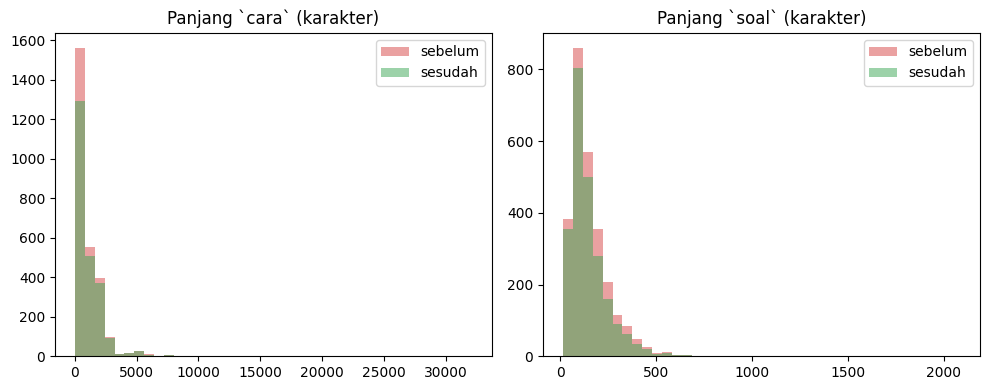

In [6]:
# Spot-check manual: sample acak biar bisa dicek mata langsung
random.seed(42)

print("=== CONTOH BARIS DIBUANG ===")
for r in random.sample(dropped, min(5, len(dropped))):
    print(f"[{r['_dropped_reason']}] soal: {r['soal'][:100]!r}")
    print(f"    jawaban: {r['jawaban'][:100]!r}\n")

repaired = [r for r in cleaned if r.get("_repair") == "stripped_letter_prefix"]
print(f"=== CONTOH BARIS DIPERBAIKI (dari {len(repaired)}) ===")
for r in random.sample(repaired, min(5, len(repaired))):
    print(f"    jawaban (bersih): {r['jawaban'][:100]!r}\n")

# Distribusi panjang soal/cara sebelum vs sesudah -- pastikan nggak ada shift aneh
def lens(rs, key):
    return [len(r.get(key) or "") for r in rs]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(lens(rows, "cara"), bins=40, alpha=0.5, label="sebelum", color="#d64545")
axes[0].hist(lens(cleaned, "cara"), bins=40, alpha=0.5, label="sesudah", color="#3aa655")
axes[0].set_title("Panjang `cara` (karakter)")
axes[0].legend()

axes[1].hist(lens(rows, "soal"), bins=40, alpha=0.5, label="sebelum", color="#d64545")
axes[1].hist(lens(cleaned, "soal"), bins=40, alpha=0.5, label="sesudah", color="#3aa655")
axes[1].set_title("Panjang `soal` (karakter)")
axes[1].legend()

plt.tight_layout()
plt.show()